In [17]:
import os
import re
import sys
import glob
import intake
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client

In [5]:
#----------------------------------------------------------------------------------------------
# Function to read file and collect data for SOTS region
#----------------------------------------------------------------------------------------------

def collect_data(var, local_path, region, start_date, end_date):

    var_arr  = []

    cleaned_list = [item for item in local_path if item != []]

    
    for item,file in enumerate(cleaned_list):

        print(f'reading file: {file.split("/")[-1]}, {item+1}/{len(cleaned_list)}')
        sys.stdout.flush()
        
        with xr.open_dataset(file,decode_timedelta=False) as ds:

            time_range = ds['time'].sel(time=slice(start_date, end_date))

            data = ds[var].sel(time=time_range,\
                            yt_ocean=slice(region[0][0], region[0][1]), \
                            xt_ocean=slice(region[1][0], region[1][1])).load()
            
            data = data.mean(dim=["yt_ocean", "xt_ocean"]) 
            
    
            original_units = ds[var].attrs.get('units', '')
            
        if original_units:
            data.attrs['units'] = original_units
    
        var_arr.append(data)

    return  var_arr
    

In [6]:
client = Client()
client

/home/562/cd3007/miniconda3/envs/mhw_env/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36841 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/36841/status,
Dashboard: /proxy/36841/status,Workers: 2
Total threads: 2,Total memory: 7.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34683,Workers: 0
Dashboard: /proxy/36841/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44563,Total threads: 1
Dashboard: /proxy/38055/status,Memory: 3.50 GiB
Nanny: tcp://127.0.0.1:44981,


In [54]:

catalog = intake.cat.access_nri


print('Starting ACCESS-OM2 SOTS net surface heat flux analysis....')
sys.stdout.flush()

#----------------------------------------------------------------------------------------------
# Date of interest 
#----------------------------------------------------------------------------------------------

start_date = np.datetime64("2010-01-01")
end_date = np.datetime64("2023-12-31")

#----------------------------------------------------------------------------------------------
# Variable of interest in ACCESS-OM1-O1
#----------------------------------------------------------------------------------------------

var   =  'net_sfc_heating'

access_model=['01deg_jra55v140_iaf','01deg_jra55v140_iaf_cycle4_jra55v150_extension']
deg = '01deg'

#----------------------------------------------------------------------------------------------
# Variable of interest of SOTS
#----------------------------------------------------------------------------------------------

var_SOTS   =  'HEAT_NET'
#----------------------------------------------------------------------------------------------
# Region of interest
#----------------------------------------------------------------------------------------------

region_lat   = np.array([-50,-45])                    # yt_ocean,N
region_lon   = np.array([145,150])                    # xt_ocean,E
region_lon   = region_lon - 360                         # -> [-213, -205]

region = [region_lat, region_lon]

#----------------------------------------------------------------------------------------------
# This section collects all the variable paths for ACCESS-OM2
#----------------------------------------------------------------------------------------------
path_dict = {var: []}

catalogs = []

for model in access_model:
    filtered = catalog[model].search(
        variable=var,
        frequency='1mon',
        realm='ocean',
    )
    catalogs.append(filtered.df)

# Concatenate the dataframes from all models
combined_df = pd.concat(catalogs, ignore_index=True)

df = combined_df[
    (combined_df['start_date'] >= '2010-01-01') &
    (combined_df['start_date'] <= '2023-12-31') &
    (combined_df['filename'].str.contains('mean'))
]


file_list = df['path'].tolist()

path_dict[var].extend(file_list)
path_dict[var].sort(key=lambda f: tuple(map(int, re.search(r'ym_(\d{4})_(\d{2})', f).groups())))


print(f'Processing {var} variable...')
sys.stdout.flush()

path_list = path_dict[var]

#----------------------------------------------------------------------------------------------
# Call function to read path and collect data
#----------------------------------------------------------------------------------------------

local_var = collect_data(var, path_list, region, start_date, end_date)

heat_flux = xr.concat(local_var, dim='time')  # join all time together

dates = heat_flux['time'].values

units = heat_flux.attrs.get("units", "")

heat_flux.attrs['units'] = units

# Get climatology
monthly_climatology = heat_flux.groupby('time.month').mean(dim='time')

years = np.unique(heat_flux['time.year'].values)



Starting ACCESS-OM2 SOTS net surface heat flux analysis....
Processing net_sfc_heating variable...
reading file: ocean-2d-net_sfc_heating-1-monthly-mean-ym_2010_01.nc, 1/96
reading file: ocean-2d-net_sfc_heating-1-monthly-mean-ym_2010_04.nc, 2/96
reading file: ocean-2d-net_sfc_heating-1-monthly-mean-ym_2010_07.nc, 3/96
reading file: ocean-2d-net_sfc_heating-1-monthly-mean-ym_2010_10.nc, 4/96
reading file: ocean-2d-net_sfc_heating-1-monthly-mean-ym_2011_01.nc, 5/96
reading file: ocean-2d-net_sfc_heating-1-monthly-mean-ym_2011_04.nc, 6/96
reading file: ocean-2d-net_sfc_heating-1-monthly-mean-ym_2011_07.nc, 7/96
reading file: ocean-2d-net_sfc_heating-1-monthly-mean-ym_2011_10.nc, 8/96
reading file: ocean-2d-net_sfc_heating-1-monthly-mean-ym_2012_01.nc, 9/96
reading file: ocean-2d-net_sfc_heating-1-monthly-mean-ym_2012_04.nc, 10/96
reading file: ocean-2d-net_sfc_heating-1-monthly-mean-ym_2012_07.nc, 11/96
reading file: ocean-2d-net_sfc_heating-1-monthly-mean-ym_2012_10.nc, 12/96
reading fi

In [62]:

#----------------------------------------------------------------------------------------------
# Read and collect data for SOTS
#----------------------------------------------------------------------------------------------

print(f'Processing SOTS data...')
sys.stdout.flush()


SOTS_dir  = '/g/data/jk72/mxr581/SOTS-project-data/sots/flux'
SOTS_pattern = os.path.join(SOTS_dir, "IMOS_DWM-*_CFMST_20*.nc")

SOTS_paths = sorted(glob.glob(SOTS_pattern))

ds = xr.open_mfdataset(
    SOTS_paths,
    combine='nested',
    concat_dim='TIME',
    data_vars='minimal',
    coords='minimal',
    compat='override',
    preprocess=lambda ds: ds.sortby('TIME')  # sort each dataset's time coordinate
)[[var_SOTS]]


SOTS_flux = ds[var_SOTS]

# Get climatology
SOTS_monthly_climatology = SOTS_flux.groupby('TIME.month').mean(dim='TIME')

SOTS_years = np.unique(SOTS_flux['TIME.year'].values)

print(f'Finished collecting SOTS data.')
sys.stdout.flush()


Processing SOTS data...
Finished collecting SOTS data.


/home/562/cd3007/miniconda3/envs/mhw_env/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 35.45 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


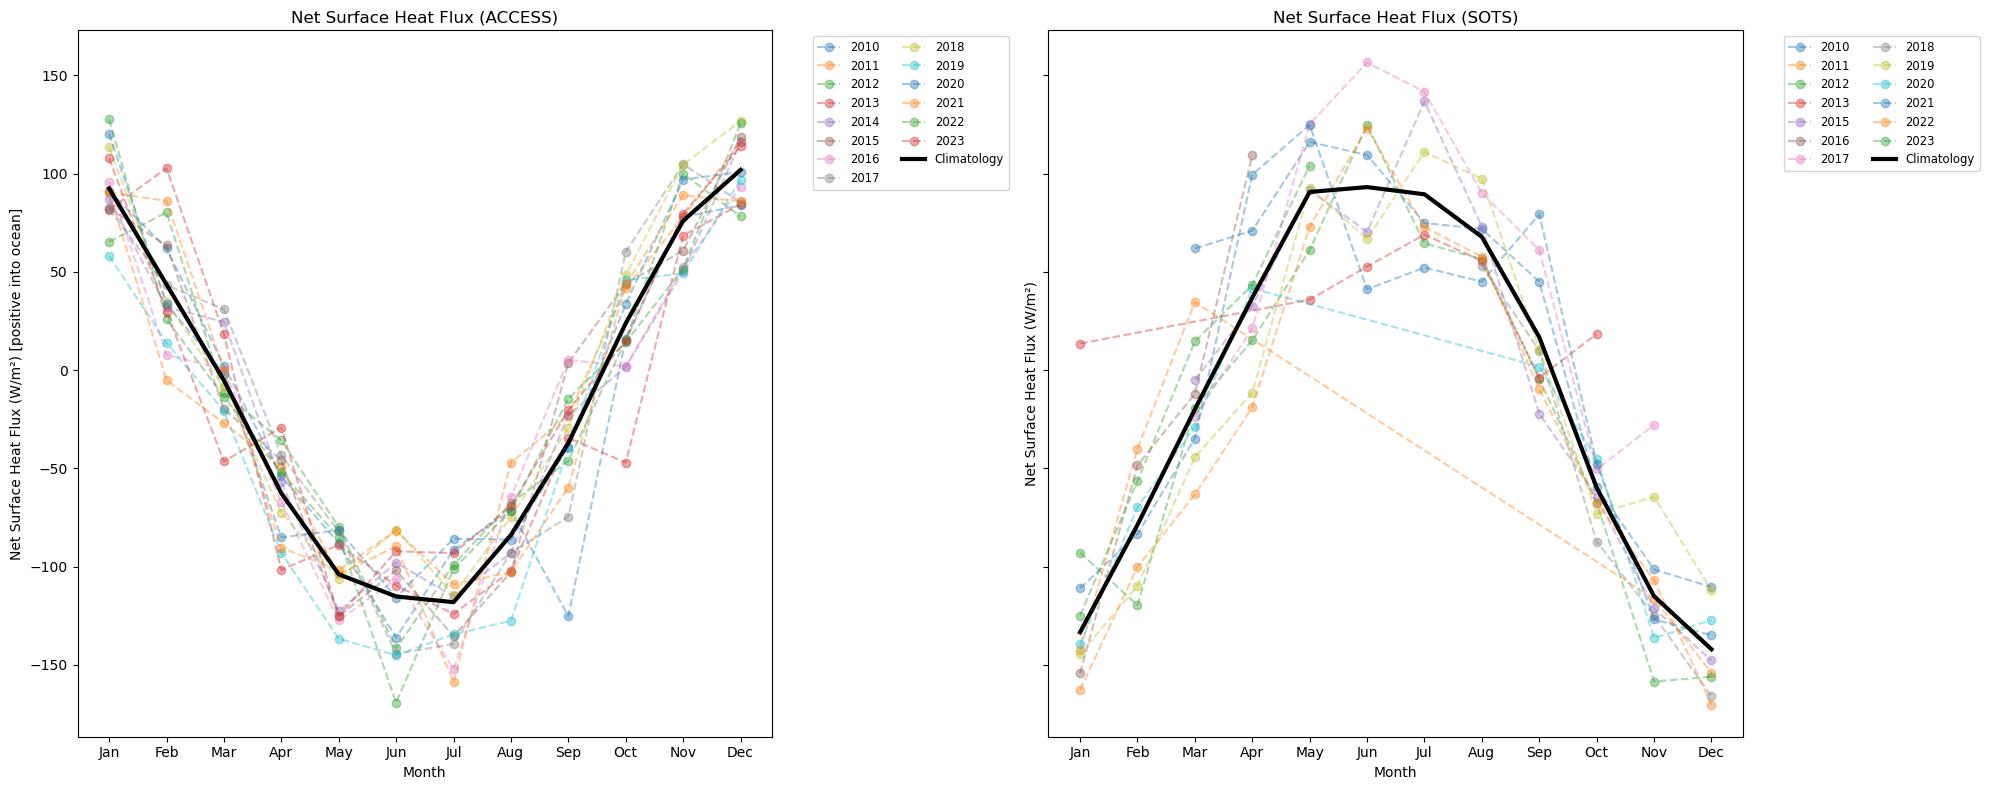

In [64]:
#----------------------------------------------------------------------------------------------
# PLOTS
#----------------------------------------------------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# ACCESS data on left plot
for yr in years:
    
    yearly = heat_flux.sel(time=str(yr))

    # Get monthly values
    months = yearly['time'].dt.month
    monthly_vals = yearly.values

    axs[0].plot(months, monthly_vals,
                label=str(yr), alpha=0.4, marker='o', linestyle='--')

axs[0].plot(monthly_climatology['month'], monthly_climatology.values,
            label='Climatology', color='black', linewidth=3)

axs[0].set_xlabel('Month')
axs[0].set_ylabel('Net Surface Heat Flux (W/m²) [positive into ocean]')
axs[0].set_title('Net Surface Heat Flux (ACCESS)')
axs[0].set_xticks(np.arange(1, 13))
axs[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axs[0].legend(ncol=2, fontsize='small', loc='upper left', bbox_to_anchor=(1.05, 1))

# SOTS data on right plot
for yr in SOTS_years:

    yearly = SOTS_flux.sel(TIME=str(yr))

    monthly_mean = yearly.groupby('TIME.month').mean(dim='TIME')
    months = monthly_mean['month']
    monthly_vals = monthly_mean.values

    axs[1].plot(months, monthly_vals,
                label=str(yr), alpha=0.4, marker='o', linestyle='--')

axs[1].plot(SOTS_monthly_climatology['month'], SOTS_monthly_climatology.values,
            label='Climatology', color='black', linewidth=3)

axs[1].set_xlabel('Month')
axs[1].set_ylabel('Net Surface Heat Flux (W/m²)')
axs[1].set_title('Net Surface Heat Flux (SOTS)')
axs[1].set_xticks(np.arange(1, 13))
axs[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axs[1].legend(ncol=2, fontsize='small', loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()
